Saving animation - this may take a minute...
Animation saved as 'spin_animation.gif'


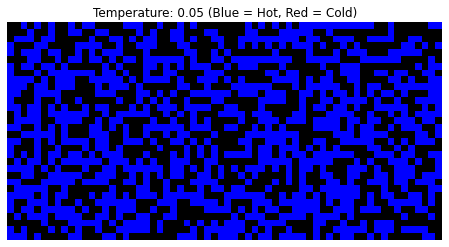

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import random
import math
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------
# Simulation and Display Settings
# -------------------------------
H, W = 32, 64       # grid dimensions (rows, columns)
N = H * W           # total number of spins
T_START = 1.0       # starting temperature
T_MIN = 0.05        # minimum temperature before reset
PERIOD = 700000     # total iterations over which temperature decreases

# Global simulation state
counter = 0
temp = T_START

# The spins: 1 means "up" (active) and -1 means "down" (off)
# We store them as a 1D array (flattened index: n = i + j*H)
spins = np.ones(N, dtype=int)
# Initialize with some randomness to make the simulation more interesting
for i in range(N):
    if random.random() < 0.3:  # Initialize ~30% of spins as -1
        spins[i] = -1

# -------------------------------
# Build Neighbor (Adjacency) Arrays
# -------------------------------
# For each pixel (i,j) with index n = i + j*H, we define its 4 neighbors.
# Order: [down, right, up, left] with wrap-around (periodic boundary conditions).
A = np.empty((N, 4), dtype=int)
for j in range(W):
    for i in range(H):
        n = i + j * H
        A[n, 0] = ((i + 1) % H) + j * H             # down neighbor (wrap vertically)
        A[n, 1] = i + (((j + 1) % W) * H)             # right neighbor (wrap horizontally)
        A[n, 2] = ((i - 1) % H) + j * H               # up neighbor
        A[n, 3] = i + (((j - 1) % W) * H)             # left neighbor

# -------------------------------
# Set Up Interaction Weights
# -------------------------------
# F is a flag array indicating whether a weight has been assigned.
# J will hold the Gaussian random interaction weights.
F = np.ones((N, 4), dtype=bool)
J = np.zeros((N, 4), dtype=float)

# For the Gaussian generator we use Python's built‑in gauss.
def gaussRan():
    return random.gauss(0, 1)

# Assign weights along edges, making sure that the weight is shared between a node and its neighbor.
for n in range(N):
    for j_dir in range(4):
        if F[n, j_dir]:
            J[n, j_dir] = gaussRan()
            F[n, j_dir] = False
            nnode = A[n, j_dir]
            # Find the corresponding reverse neighbor and set the same weight
            for k in range(4):
                if A[nnode, k] == n and F[nnode, k]:
                    J[nnode, k] = J[n, j_dir]
                    F[nnode, k] = False

# -------------------------------
# Create a custom Blue to Red colormap (inverted from previous)
# -------------------------------
# Define the custom colormap (blue to red)
cmap_br = LinearSegmentedColormap.from_list('BlueToRed', 
                                           [(0, 0, 1),       # Blue for high temperature
                                            (0.25, 0, 0.75),  # Purple-blue for high-mid temperature
                                            (0.5, 0, 0.5),   # Purple for mid temperature
                                            (1, 0, 0)])      # Red for low temperature

# -------------------------------
# Color Mapping Function
# -------------------------------
def get_color_for_spin_up(temp):
    # Normalize temperature to [0, 1] where 1 is hot (blue) and 0 is cold (red)
    # INVERTED: high temp = blue, low temp = red
    normalized_temp = (temp - T_MIN) / (T_START - T_MIN)
    # Get RGB values from our colormap
    r, g, b = cmap_br(normalized_temp)[:3]
    # Convert to 0-255 range for image display
    return (int(r*255), int(g*255), int(b*255))

# Color for spin down is always black
spin_down_color = (0, 0, 0)

# Initialize current color based on starting temperature
current_spin_up_color = get_color_for_spin_up(temp)

# -------------------------------
# Display Image Setup
# -------------------------------
# We maintain a (H x W x 3) uint8 array to represent the RGB image.
display_img = np.zeros((H, W, 3), dtype=np.uint8)

def update_display_image():
    global display_img, spins, current_spin_up_color
    spin_grid = spins.reshape((H, W))
    
    # First set all to black (for -1 spins)
    display_img[:] = spin_down_color
    
    # Then set the +1 spins to the temperature-dependent color
    display_img[spin_grid == 1] = current_spin_up_color

# Initialize display
update_display_image()

# -------------------------------
# Matplotlib Animation Setup
# -------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(display_img, interpolation='nearest')
ax.axis('off')  # hide axes

# Add title with temperature and color information
title = ax.set_title(f"Temperature: {temp:.2f} (Blue = Hot, Red = Cold)")

# Animation settings for 30-second GIF
fps = 30
total_frames = 30 * fps  # 30 seconds at 30 fps = 900 frames

def update(frame):
    global spins, counter, temp, current_spin_up_color
    iterations_per_frame = 500  # Adjusted to show more dynamics per frame
    
    for _ in range(iterations_per_frame):
        i = random.randint(0, H - 1)
        j = random.randint(0, W - 1)
        n = i + j * H

        # Compute the weighted sum over neighbors
        sw = (J[n, 0] * spins[A[n, 0]] +
              J[n, 1] * spins[A[n, 1]] +
              J[n, 2] * spins[A[n, 2]] +
              J[n, 3] * spins[A[n, 3]])
        de = 2 * spins[n] * sw

        # Monte Carlo probability rule using the Boltzmann factor
        r_val = math.exp(-de / temp)
        p = r_val if r_val < 1.0 else 1.0
        if p > random.random():
            spins[n] *= -1  # flip the spin

    # Update temperature linearly across all frames for a smooth transition
    if frame < total_frames:
        temp = T_START - (T_START - T_MIN) * (frame / total_frames)
    else:
        # Reset if we go beyond total frames
        temp = T_MIN
    
    # Update the current color for spin-up (+1) based on temperature
    current_spin_up_color = get_color_for_spin_up(temp)
    
    # Update the title with current temperature
    title.set_text(f"Temperature: {temp:.2f} (Blue = Hot, Red = Cold)")
    
    # Update the display image
    update_display_image()
    im.set_array(display_img)
    
    # Return what we've updated
    return [im, title]

# Create the animation
ani = animation.FuncAnimation(fig, update, frames=total_frames, interval=1000/fps, blit=True)

# Save the animation to a GIF file
print("Saving animation - this may take a minute...")
writer = animation.PillowWriter(fps=fps)
ani.save("spin_animation.gif", writer=writer)

print("Animation saved as 'spin_animation.gif'")

# Display the animation window
plt.show()